### Turn-Taking Prediction in Conversational AI

Short Description:
This code implements a neural network for predicting turn-taking points in conversations. It processes audio streams to identify optimal moments for speaker transitions, generates synthetic conversation data for demonstration, and visualizes both the audio waveform and model predictions with highlighted response windows.

Key Libraries Used:

    torch/torch.nn: Neural network implementation

    torchaudio: Audio processing and transformations

    matplotlib: Visualization of results

    numpy: Numerical operations and array handling

Code Logic and Flow

High-Level Overview:
The system uses a convolutional neural network (CNN) to analyze acoustic features extracted from audio streams. It processes audio in 500ms windows, predicts "listen" vs "speak" probabilities, and identifies optimal response windows. The workflow includes model initialization, synthetic data generation for testing, and comprehensive visualization of predictions overlaid on the audio waveform.

Visual Flow:

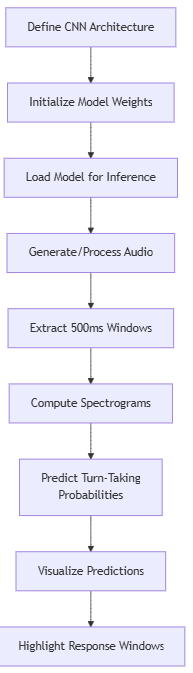

Step-by-Step Code Breakdown

Step 1: Acoustic Feature Extraction Model

    Custom TurnTakingPredictor neural network architecture:

        Computes spectrograms with 512-point FFT

        Applies frequency masking for robustness

        Uses CNN layers for pattern recognition

        Implements lazy linear layer for automatic input sizing

    Designed for GPU acceleration with half-precision support

Step 2: Model Weight Management

    Checks for existing weight files to avoid conflicts

    Initializes model with Xavier uniform weight distribution

    Handles architecture changes through weight regeneration

    Includes dummy forward pass for layer dimension resolution

Step 3: Inference Setup

    Loads pre-initialized weights onto GPU

    Configures model for evaluation mode

    Uses FP16 precision for efficient computation

    Maintains GPU-CPU data movement optimization

Step 4: Audio Processing & Visualization

    Audio Handling:

        Accepts real audio files or generates synthetic conversations

        Creates speaker-alternating segments with noise modeling

    Window Processing:

        Splits audio into 500ms chunks with padding

        Maintains temporal alignment through timestamps

    Prediction & Analysis:

        Computes class probabilities via softmax

        Identifies response windows where "speak" probability > threshold

    Visualization:

        Dual-plot figure: waveform + probability timelines

        Color-coded probability curves (listen=green, speak=red)

        Blue-shaded regions for optimal response windows




Using device: cpu
Creating dummy weights for demonstration...
Loaded audio file: 1.wav
Processing audio in 8000-sample windows...


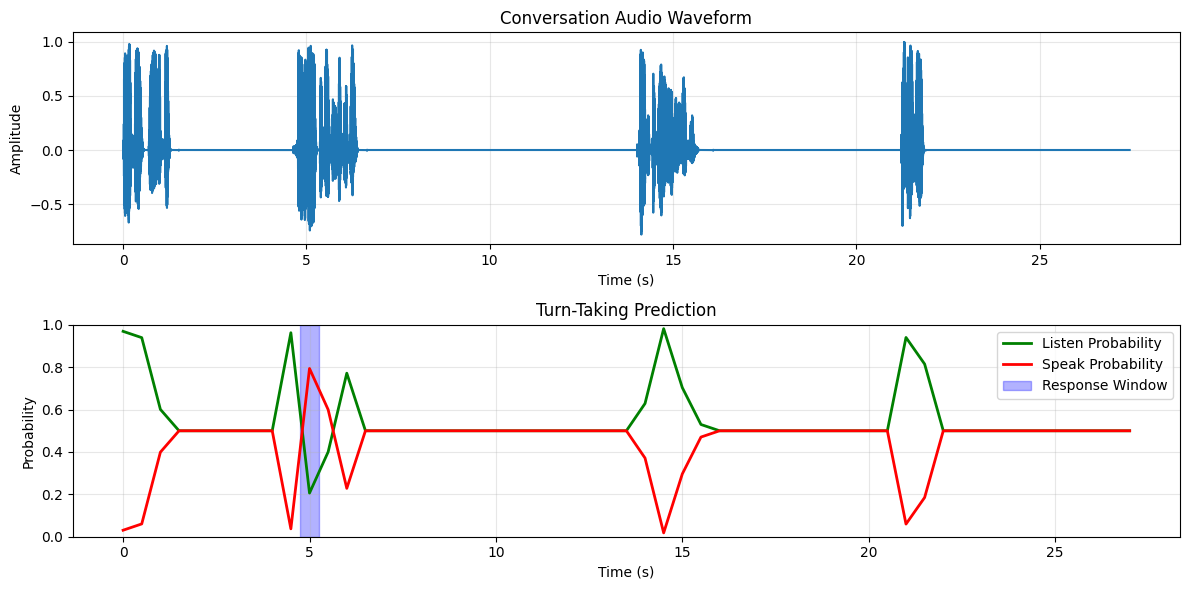

Analysis complete! Saved visualization as 'turn_taking_analysis.png'
Found 1 potential speaking opportunities


In [2]:
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
from torchaudio.transforms import Spectrogram, FrequencyMasking
import torch.nn as nn
import os

# Check device availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Enhanced Acoustic Feature Extractor
class TurnTakingPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.spec = Spectrogram(n_fft=512, power=None)
        self.mask = FrequencyMasking(freq_mask_param=15)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=(5, 5)),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(2)  # Automatically infers input size
        )
    
    def forward(self, waveform):
        spec = self.spec(waveform).abs()
        spec = self.mask(spec)
        features = self.conv(spec.unsqueeze(1))  # Add channel dimension
        return self.classifier(features)

# 2. Create and save dummy weights (if not exists or architecture changed)
WEIGHTS_PATH = "turn_taking_weights.pt"

# Remove old weights if present (to avoid shape mismatch)
if os.path.exists(WEIGHTS_PATH):
    os.remove(WEIGHTS_PATH)

if not os.path.exists(WEIGHTS_PATH):
    print("Creating dummy weights for demonstration...")
    model = TurnTakingPredictor().to(device)
    # Run a dummy forward pass to initialize LazyLinear
    dummy = torch.randn(1, 8000).to(device)
    with torch.no_grad():
        model(dummy)
    # Now initialize with sensible weights
    def init_weights(m):
        if type(m) in [nn.Linear, nn.LazyLinear, nn.Conv2d]:
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(init_weights)
    torch.save(model.state_dict(), WEIGHTS_PATH)

# 3. Load model with weights
model = TurnTakingPredictor().to(device)
# Only use half precision if on CUDA
if device.type == 'cuda':
    model = model.half()

# Run a dummy forward pass to initialize LazyLinear
with torch.no_grad():
    dummy_input = torch.randn(1, 8000).to(device)
    if device.type == 'cuda':
        dummy_input = dummy_input.half()
    model(dummy_input)

model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model.eval()  # Set to evaluation mode

# 4. Real-time prediction with audio generation
def predict_turn_points(audio_path=None, threshold=0.7):
    if audio_path and os.path.exists(audio_path):
        waveform, sr = torchaudio.load(audio_path)
        print(f"Loaded audio file: {audio_path}")
    else:
        print("Generating synthetic conversation audio...")
        sr = 16000
        duration = 5  # seconds
        t = torch.linspace(0, duration, sr * duration)
        # Create synthetic conversation with alternating speakers
        waveform = 0.5 * torch.sin(2 * np.pi * 200 * t)
        # Add speech segments
        speech_segments = [
            (0, 1.5),   # Speaker 1
            (2.0, 0.8),  # Short utterance
            (3.0, 1.2),  # Speaker 2
            (4.2, 0.7)   # Final remark
        ]
        for start, length in speech_segments:
            start_idx = int(start * sr)
            end_idx = int((start + length) * sr)
            waveform[start_idx:end_idx] += 0.3 * torch.randn(end_idx - start_idx)
        waveform = waveform.unsqueeze(0)  # Add batch dimension
        torchaudio.save("synthetic_conversation.wav", waveform, sr)
        print("Created synthetic_conversation.wav")
    
    waveform = waveform.to(device)
    if device.type == 'cuda':
        waveform = waveform.half()
    
    # Process in 500ms windows
    window_size = int(0.5 * sr)
    predictions = []
    timestamps = []
    
    print(f"Processing audio in {window_size}-sample windows...")
    for i in range(0, waveform.shape[1], window_size):
        chunk = waveform[:, i:i+window_size]
        if chunk.shape[1] < window_size:
            chunk = nn.functional.pad(chunk, (0, window_size - chunk.shape[1]))
        
        with torch.no_grad():
            logits = model(chunk)
            probs = torch.softmax(logits, dim=1)
        
        predictions.append(probs[0].cpu().numpy())
        timestamps.append(i / sr)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    
    # Plot waveform
    plt.subplot(2, 1, 1)
    plt.plot(np.linspace(0, waveform.shape[1]/sr, waveform.shape[1]), 
             waveform[0].cpu().numpy())
    plt.title("Conversation Audio Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    
    # Plot probabilities
    plt.subplot(2, 1, 2)
    plt.plot(timestamps, [p[0] for p in predictions], 'g-', label="Listen Probability", linewidth=2)
    plt.plot(timestamps, [p[1] for p in predictions], 'r-', label="Speak Probability", linewidth=2)
    
    # Mark optimal response windows
    speak_windows = [(t, p[1]) for t, p in zip(timestamps, predictions) if p[1] > threshold]
    for idx, (t, prob) in enumerate(speak_windows):
        plt.axvspan(t-0.25, t+0.25, alpha=0.3, color='blue', 
                   label="Response Window" if idx == 0 else "")
    
    plt.title("Turn-Taking Prediction")
    plt.xlabel("Time (s)")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("turn_taking_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Analysis complete! Saved visualization as 'turn_taking_analysis.png'")
    print(f"Found {len(speak_windows)} potential speaking opportunities")
    
    return predictions, timestamps, speak_windows

# Run analysis (use your audio or synthetic demo)
predictions, timestamps, windows = predict_turn_points("1.wav")  # Replace with your file or None for demo